In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn import tree 


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from pickle import dump
import json


# CARGAR EL DATA SET

In [37]:
url = ('../data/raw/diabetes.csv')
df = pd.read_csv(url)

print("Dataset original:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nValores nulos:\n{df.isnull().sum()}")

Dataset original:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape: (768, 9)

Valores nulos:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome     

In [38]:
# Limpiar ceros
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
for col in cols_with_zeros:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nDatos limpios (ceros reemplazados por mediana):")
print(df_clean.describe())


Datos limpios (ceros reemplazados por mediana):
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.331329   11.760232 

# Crear datasets CON y SIN outliers

In [39]:
# Separar X e y
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# Split train/test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Dataset CON outliers 

In [40]:
X_train_CON_outliers = X_train_full.copy()
y_train = y_train_full.copy()

print("X_train_CON_outliers:")
print(f"Shape: {X_train_CON_outliers.shape}")
print(X_train_CON_outliers.head())

X_train_CON_outliers:
Shape: (614, 8)
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
353            1     90.0           62.0           12.0     43.0  27.2   
711            5    126.0           78.0           27.0     22.0  29.6   
373            2    105.0           58.0           40.0     94.0  34.9   
46             1    146.0           56.0           29.0    125.0  29.7   
682            0     95.0           64.0           39.0    105.0  44.6   

     DiabetesPedigreeFunction  Age  
353                     0.580   24  
711                     0.439   40  
373                     0.225   25  
46                      0.564   29  
682                     0.366   22  


# Dataset SIN outliers

In [41]:
z_scores = np.abs(stats.zscore(X_train_full))
mask_sin_outliers = (z_scores < 3).all(axis=1)

X_train_SIN_outliers = X_train_full[mask_sin_outliers].copy()
y_train_sin = y_train_full[mask_sin_outliers].copy()

print("="*60)
print("X_train_SIN_outliers")
print("="*60)
print(f"Shape: {X_train_SIN_outliers.shape}")
print(f"Registros eliminados: {len(X_train_full) - len(X_train_SIN_outliers)}")
print(X_train_SIN_outliers.head())

X_train_SIN_outliers
Shape: (574, 8)
Registros eliminados: 40
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
353            1     90.0           62.0           12.0     43.0  27.2   
711            5    126.0           78.0           27.0     22.0  29.6   
373            2    105.0           58.0           40.0     94.0  34.9   
46             1    146.0           56.0           29.0    125.0  29.7   
682            0     95.0           64.0           39.0    105.0  44.6   

     DiabetesPedigreeFunction  Age  
353                     0.580   24  
711                     0.439   40  
373                     0.225   25  
46                      0.564   29  
682                     0.366   22  


# Visualización comparativa

/tmp/ipykernel_791/270662438.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([X_train_CON_outliers[col], X_train_SIN_outliers[col]],
/tmp/ipykernel_791/270662438.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([X_train_CON_outliers[col], X_train_SIN_outliers[col]],
/tmp/ipykernel_791/270662438.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([X_train_CON_outliers[col], X_train_SIN_outliers[col]],
/tmp/ipykernel_791/270662438.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

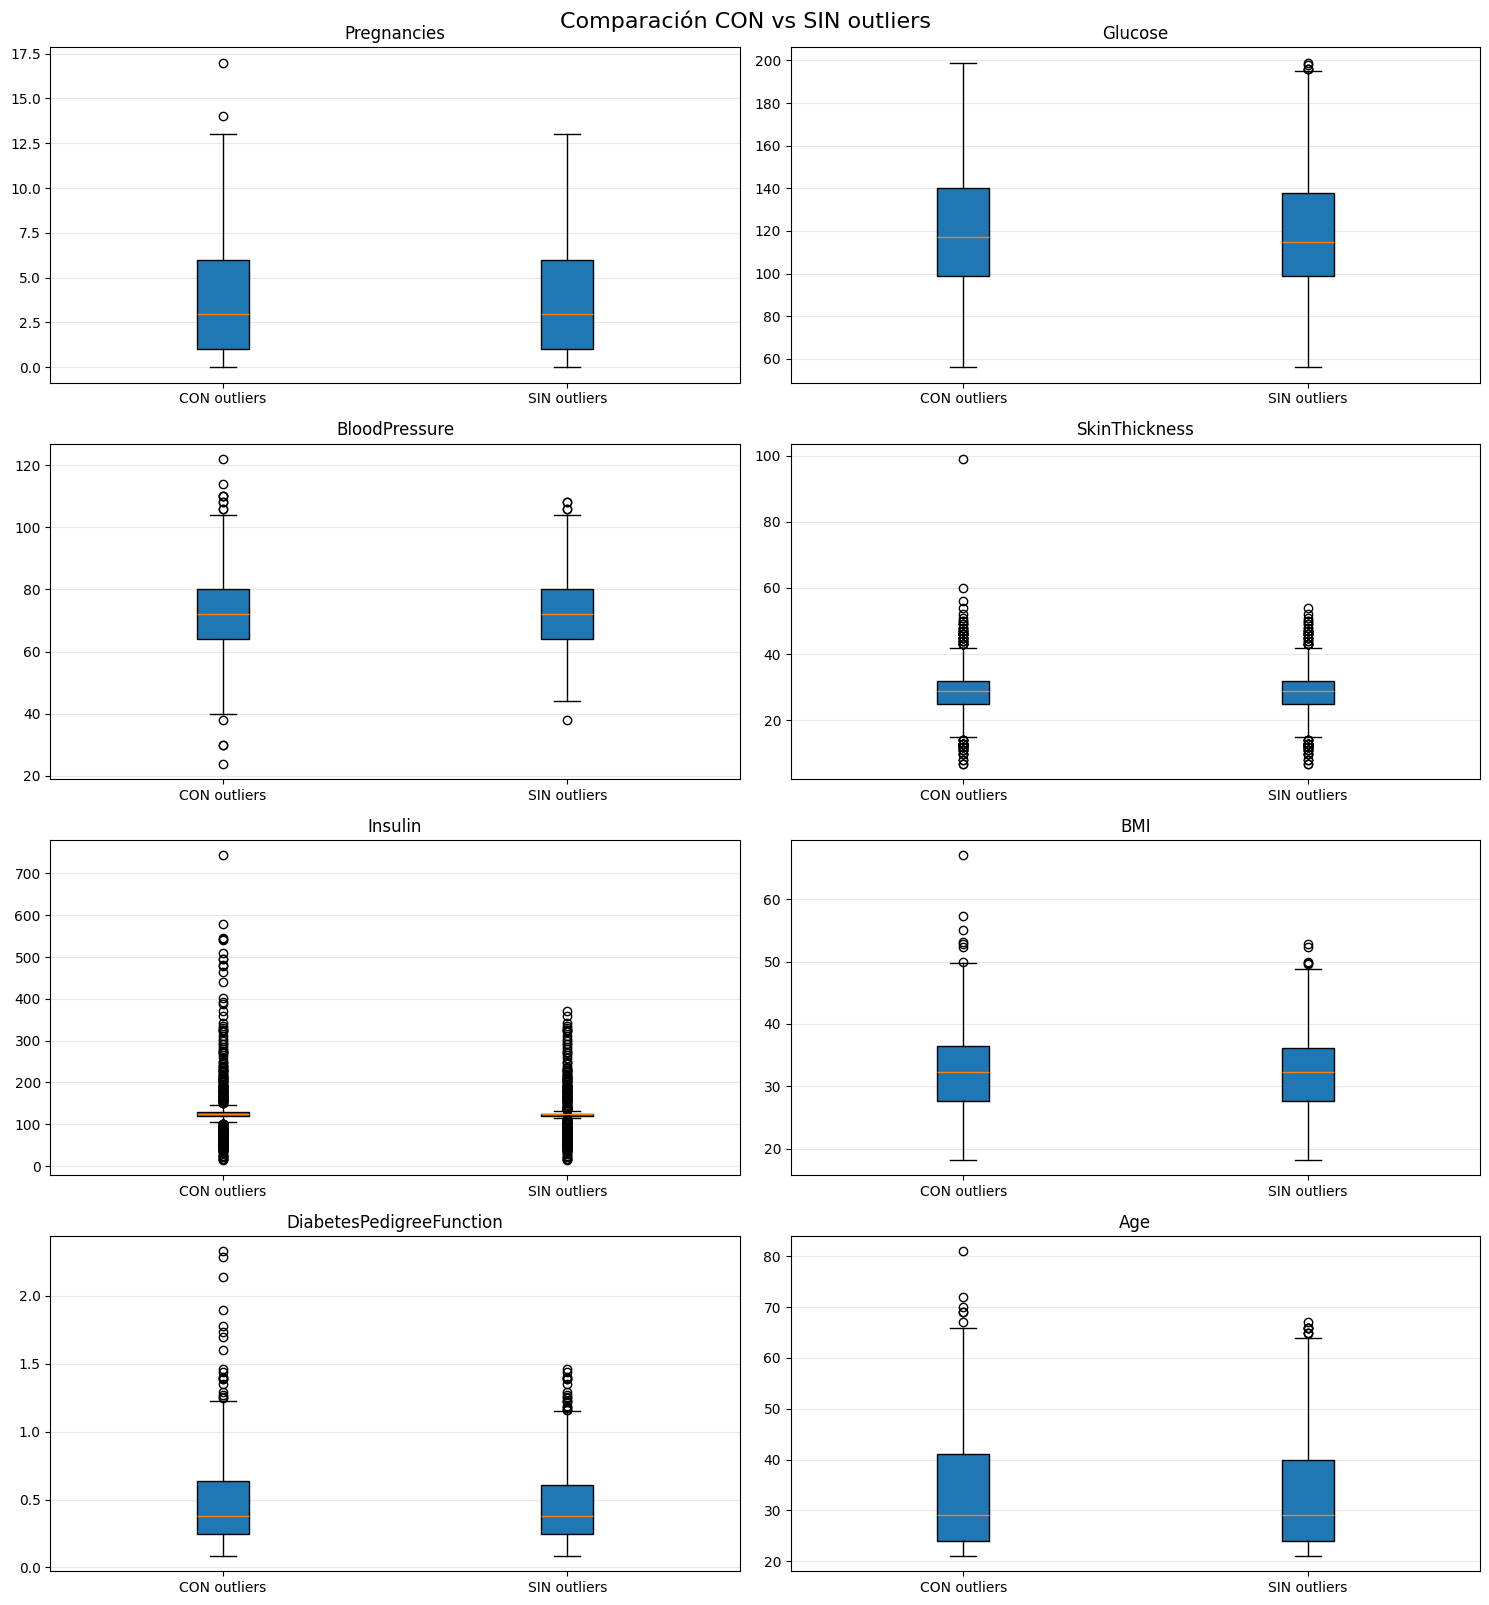

In [42]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()

for idx, col in enumerate(X.columns):
    axes[idx].boxplot([X_train_CON_outliers[col], X_train_SIN_outliers[col]], 
                       labels=['CON outliers', 'SIN outliers'],
                       patch_artist=True)
    axes[idx].set_title(f'{col}')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Comparación CON vs SIN outliers', fontsize=16, y=1.00)
plt.show()

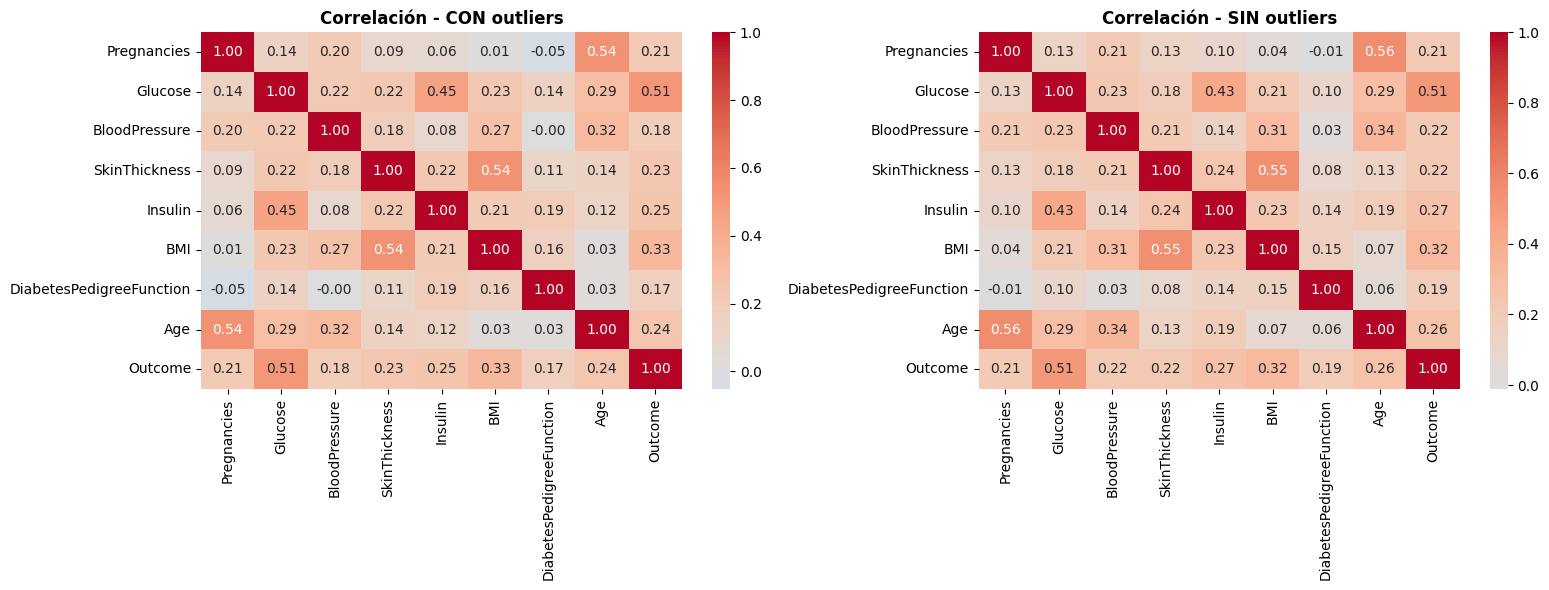

In [43]:
# Matrices de correlación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# CON outliers
corr_con = pd.concat([X_train_CON_outliers, y_train], axis=1).corr()
sns.heatmap(corr_con, annot=True, cmap='coolwarm', fmt='.2f', ax=ax1, center=0)
ax1.set_title('Correlación - CON outliers', fontweight='bold')

# SIN outliers
corr_sin = pd.concat([X_train_SIN_outliers, y_train_sin], axis=1).corr()
sns.heatmap(corr_sin, annot=True, cmap='coolwarm', fmt='.2f', ax=ax2, center=0)
ax2.set_title('Correlación - SIN outliers', fontweight='bold')

plt.tight_layout()
plt.show()

In [44]:
# Comparar correlaciones con Outcome
print("Correlación con Outcome (Diabetes):")
print("\nCON outliers:")
print(corr_con['Outcome'].sort_values(ascending=False))
print("\nSIN outliers:")
print(corr_sin['Outcome'].sort_values(ascending=False))

Correlación con Outcome (Diabetes):

CON outliers:
Outcome                     1.000000
Glucose                     0.512291
BMI                         0.328830
Insulin                     0.245902
Age                         0.240676
SkinThickness               0.234260
Pregnancies                 0.208173
BloodPressure               0.183373
DiabetesPedigreeFunction    0.165312
Name: Outcome, dtype: float64

SIN outliers:
Outcome                     1.000000
Glucose                     0.505842
BMI                         0.316356
Insulin                     0.268655
Age                         0.257850
BloodPressure               0.219478
SkinThickness               0.217349
Pregnancies                 0.210374
DiabetesPedigreeFunction    0.192172
Name: Outcome, dtype: float64


# Selección del mejor dataset

In [53]:
# Probar un modelo simple con cada dataset para ver cuál es mejor

from sklearn.model_selection import cross_val_score

datasets = [
    (X_train_CON_outliers, y_train, "CON_outliers"),
    (X_train_SIN_outliers, y_train_sin, "SIN_outliers")
]

models = []
metrics = []
names = []

print("EVALUACIÓN DE DATASETS (usando validación cruzada)")

for X_data, y_data, name in datasets:
    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=5,  # limite de profundidad para evitar overfitting
        min_samples_split=10,
        min_samples_leaf=5
    )
    
    # VALIDACIÓN CRUZADA 
    scores = cross_val_score(model, X_data, y_data, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    
    # También entrenamos el modelo completo
    model.fit(X_data, y_data)
    y_pred_train = model.predict(X_data)
    train_score = accuracy_score(y_data, y_pred_train)
    
    models.append(model)
    metrics.append(mean_score)  # Usamos CV score, no train score
    names.append(name)
    
    print(f"\n{name}:")
    print(f"  - Accuracy en TRAIN: {train_score:.4f}")
    print(f"  - Accuracy en CV (validación): {mean_score:.4f} (±{scores.std():.4f})")
    print(f"  - CV Scores individuales: {scores}")

best_metric = max(metrics)
best_index = metrics.index(best_metric)

print(f" El mejor dataset es: {names[best_index]}")
print(f" Accuracy (CV): {best_metric:.4f}")

# Guardar el mejor dataset para siguiente paso
X_train_best = datasets[best_index][0]
y_train_best = datasets[best_index][1]

EVALUACIÓN DE DATASETS (usando validación cruzada)

CON_outliers:
  - Accuracy en TRAIN: 0.8013
  - Accuracy en CV (validación): 0.7101 (±0.0127)
  - CV Scores individuales: [0.71544715 0.70731707 0.69918699 0.73170732 0.69672131]

SIN_outliers:
  - Accuracy en TRAIN: 0.7997
  - Accuracy en CV (validación): 0.7352 (±0.0268)
  - CV Scores individuales: [0.70434783 0.76521739 0.70434783 0.73913043 0.76315789]
 El mejor dataset es: SIN_outliers
 Accuracy (CV): 0.7352


# Definir grid de parámetros

In [46]:
params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [None, "sqrt", "log2"]
}

total_combinaciones = 2 * 5 * 3 * 3 * 3

print("OPTIMIZACIÓN CON GRID SEARCH")
print(f"Total de combinaciones a probar: {total_combinaciones}")

OPTIMIZACIÓN CON GRID SEARCH
Total de combinaciones a probar: 270


In [47]:
# Grid Search con validación cruzada
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42), 
    params, 
    scoring="accuracy",
    cv=5,  # 5-fold cross validation
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_best, y_train_best)

print("RESULTADOS DE LA OPTIMIZACIÓN")
print(f"\nMejores parámetros encontrados:")
for param, value in grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor score (CV): {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


RESULTADOS DE LA OPTIMIZACIÓN

Mejores parámetros encontrados:
  criterion: entropy
  max_depth: 3
  max_features: None
  min_samples_leaf: 1
  min_samples_split: 2

Mejor score (CV): 0.7477


# Evaluación del modelo optimizado en test

In [48]:
# Predecir en conjunto de test
y_pred_test = best_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("EVALUACIÓN EN CONJUNTO DE PRUEBA")
print(f"\nAccuracy en test: {accuracy_test:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_test, 
                          target_names=['No Diabetes', 'Diabetes']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
print(f"\nMatriz de confusión:")
print(cm)
print(f"\nVerdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]}  (diabetes no detectada - CRÍTICO)")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")

EVALUACIÓN EN CONJUNTO DE PRUEBA

Accuracy en test: 0.6883

Reporte de clasificación:
              precision    recall  f1-score   support

 No Diabetes       0.70      0.92      0.79       100
    Diabetes       0.64      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.67      0.59      0.58       154
weighted avg       0.68      0.69      0.64       154


Matriz de confusión:
[[92  8]
 [40 14]]

Verdaderos Negativos (TN): 92
Falsos Positivos (FP): 8
Falsos Negativos (FN): 40  (diabetes no detectada - CRÍTICO)
Verdaderos Positivos (TP): 14


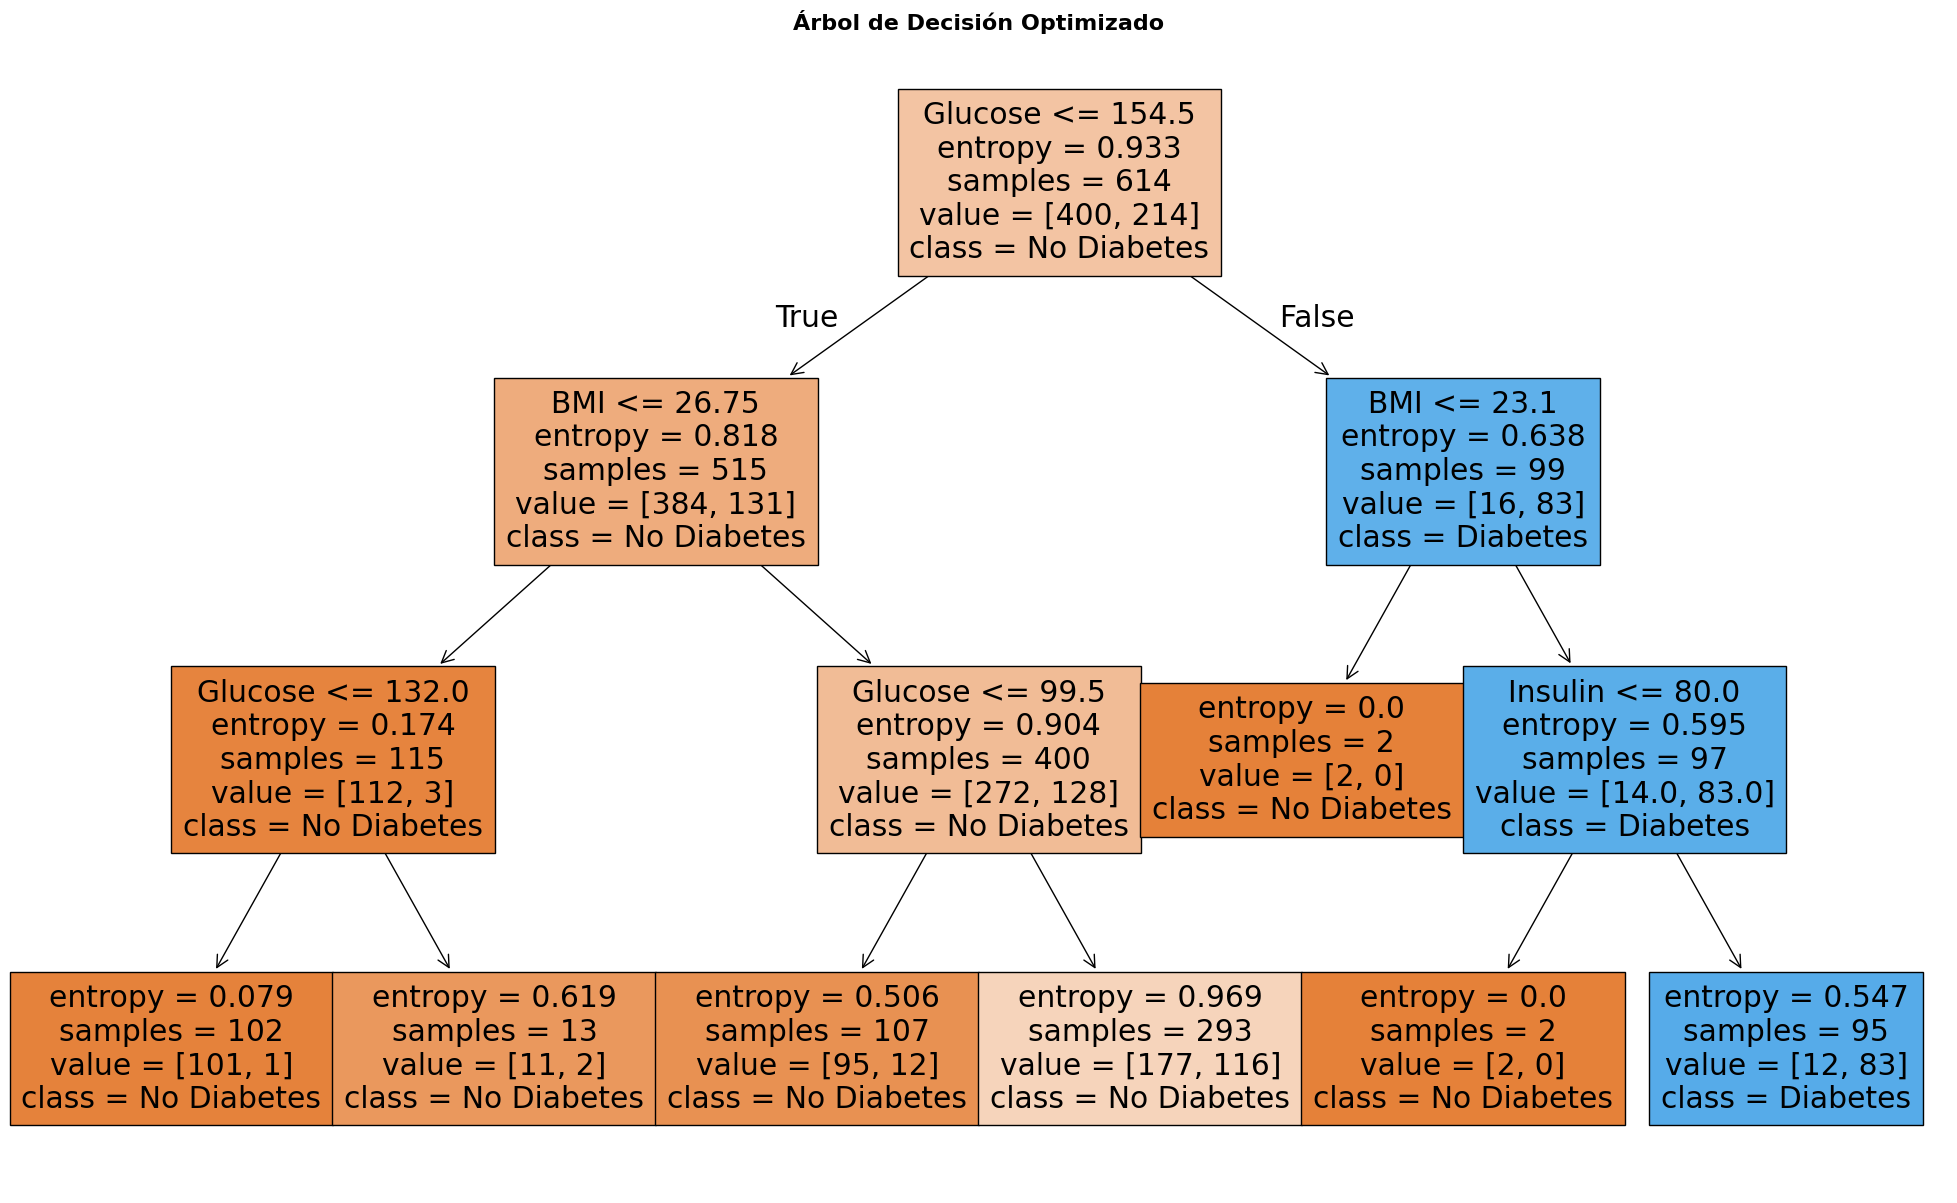

In [51]:
# Visualizar el árbol final
plt.figure(figsize=(25, 15))
tree.plot_tree(best_model, 
               feature_names=X.columns,
               class_names=['No Diabetes', 'Diabetes'],
               filled=True,
               max_depth=4)
plt.title('Árbol de Decisión Optimizado', fontsize=16, fontweight='bold')
plt.show()


Importancia de características:
             Característica  Importancia
1                   Glucose     0.695568
5                       BMI     0.269789
4                   Insulin     0.034643
0               Pregnancies     0.000000
3             SkinThickness     0.000000
2             BloodPressure     0.000000
6  DiabetesPedigreeFunction     0.000000
7                       Age     0.000000


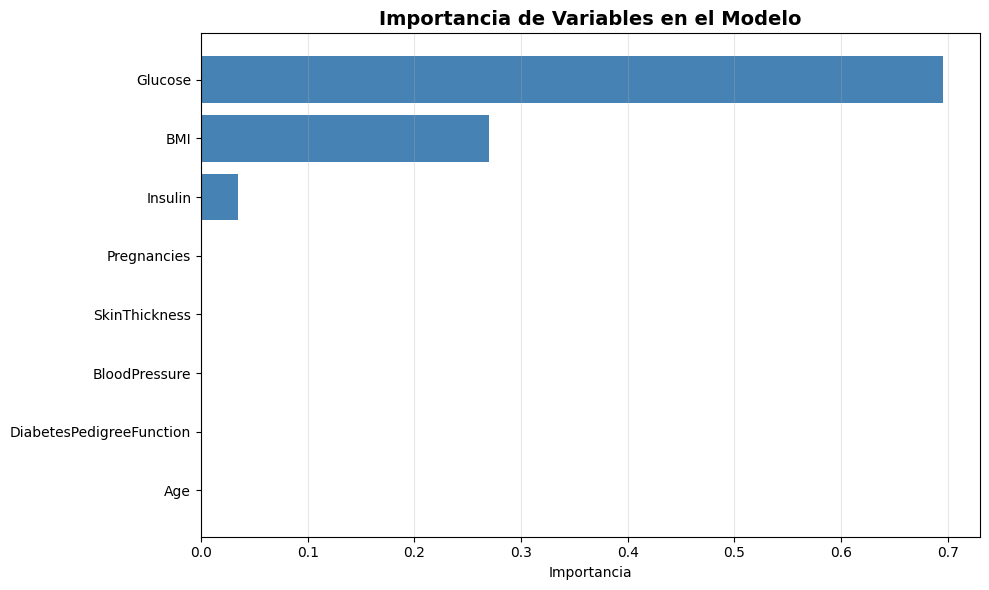

In [ ]:
# Importancia de características
importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': best_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de características:")
print(importancias)

plt.figure(figsize=(10, 6))
plt.barh(importancias['Característica'], importancias['Importancia'], color='steelblue')
plt.xlabel('Importancia')
plt.title('Importancia de Variables en el Modelo', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# GUARDAR EL MODELO

In [ ]:
# Guardar modelo
nombre_modelo = f"decision_tree_diabetes_{names[best_index]}_optimizado_42.sav"
dump(best_model, open(nombre_modelo, "wb"))
print(f" Modelo guardado: {nombre_modelo}")

# Guardar parámetros
parametros = {
    'dataset_usado': names[best_index],
    'best_params': grid.best_params_,
    'cv_score': float(grid.best_score_),
    'test_accuracy': float(accuracy_test),
    'random_state': 42,
    'feature_importances': importancias.to_dict('records')
}

with open('parametros_modelo.json', 'w') as f:
    json.dump(parametros, f, indent=4)
print(" Parámetros guardados: parametros_modelo.json")

 Modelo guardado: decision_tree_diabetes_CON_outliers_optimizado_42.sav
 Parámetros guardados: parametros_modelo.json


In [54]:
print(" RESUMEN FINAL")

print(f"""
 DATOS:
   • Total de pacientes: {len(df)}
   • Dataset seleccionado: SIN outliers ({len(X_train_best)} registros)
   • Outliers eliminados: {len(X_train_full) - len(X_train_SIN_outliers)}

 MODELO:
   • Tipo: Árbol de Decisión
   • Precisión final: {accuracy_test:.1%}
   
 ERRORES:
   • Diabetes NO detectada: {cm[1,0]} casos (lo más peligroso)
   • Falsas alarmas: {cm[0,1]} casos
   
 FACTOR MÁS IMPORTANTE:
   • {importancias.iloc[0]['Característica']} ({importancias.iloc[0]['Importancia']:.1%})

 CONCLUSIÓN:
   El modelo predice diabetes con {accuracy_test:.1%} de precisión.
   Eliminar outliers mejoró el rendimiento del modelo.
""")

 RESUMEN FINAL

 DATOS:
   • Total de pacientes: 768
   • Dataset seleccionado: SIN outliers (574 registros)
   • Outliers eliminados: 40

 MODELO:
   • Tipo: Árbol de Decisión
   • Precisión final: 68.8%

 ERRORES:
   • Diabetes NO detectada: 40 casos (lo más peligroso)
   • Falsas alarmas: 8 casos

 FACTOR MÁS IMPORTANTE:
   • Glucose (69.6%)

 CONCLUSIÓN:
   El modelo predice diabetes con 68.8% de precisión.
   Eliminar outliers mejoró el rendimiento del modelo.

